<a href="https://colab.research.google.com/github/DamianAlvarezDiaz/telecom_analysis/blob/main/Copia_de_S7_Version_Estudiante_Project_ConnectaTel_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv("/datasets/users_latam.csv")
usage = pd.read_csv("/datasets/usage.csv")

In [ ]:
# mostrar las primeras 5 filas de plans (aunque solamente existen DOS planes: "Básico" y "Premium")
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum())  # Cantidad de valores nulos
print() #salto de línea
print((users.isna().mean().sort_values(ascending=True))*100)  # Proporción de valores nulos

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
reg_date       0.000
plan           0.000
city          11.725
churn_date    88.350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print(usage.isna().sum())  # Cantidad de valores nulos
print() #salto de línea
print((usage.isna().mean().sort_values(ascending=True))*100)  # Proporción de valores nulos

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

id           0.000
user_id      0.000
type         0.000
date         0.125
length      44.740
duration    55.190
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?

En el dataset "users", la columna "city" tiene 469 valores faltantes, que representa el 11.725% del total, mientras que la columna "churn_date" arrojó 3434 valores faltantes, que equivale al 88.35% /una proporción muy alta)

Por su parte. el dataset "usage" mostró solamente 50 valores faltantes en su columna "date", que apenas representa el 0.125%, mientras que la columna "duration" tuvo 22,076 valores faltantes (44.74%) y la columna "lenght" tuvo 17,896 valores faltantes (55.19%).


   
- Indica qué harías: ¿imputar, eliminar, ignorar?

En el caso de las columnas "city" del dataset "users" y "city" del dataset "usage", lo mejor es imputar o dejar como nulos. Las columnas "duration" y "lenght" del dataset "usage" se tienen que investigar para imputar o dejar como nulos.  La columna "churn_date" del dataset "users" debe revisarse también, aunque su porcentaje de faltantes sea alto, ya que se trata de una columna importante para el análisis.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` muestra un promedio y una mediana exactamente iguales; los mínimos y máximos no se alejan demasiado de ese promedio/mediana, por lo que no parecen haber sentinels ni outliers importantes, aunque esto es de esperarse, ya que el "user_id" debiese ser una serie contínua de números asignados de forma individual y única a cada usuario.
- La columna `age` sí arroja un valor sentinel (-999, en el valor mínimo), que está distorsionando la relación entre media (33.74 años) y mediana (47.0 años). Si se elimina o imputa ese sentinel con la mediana, tendremos un resumen estadístico más confiable.

In [ ]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` muestran una proporción igual o casi igual entre media y mediana, sin valores que se alejen mucho de esta tendencia central, por lo que no parecen haber outliers o valores atípicos.
- Las columnas 'duration' y 'lenght' (que además tienen muchos valores faltantes), muestran outliers superiores que hacen que el promedio en ambas columnas sea mayor que la media. Es decir, en 'duration', el valor máximo (120) es poco más de 17 veces mayor al valor del Q3 (6.99), mientras que en 'lenght', el valor máximo (1490) es más de 23 veces mayor que el valor del Q3 (64).

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` (que tiene 469 faltantes), nos muestra que la ciudad donde más usuarios hay es Bogotá (808 usuarios), de un total de siete ciudades
- La columna `plan` dice que de los dos planes, el 'Básico' es el más popular, con 2595 usuarios (de un total de 4,000)

In [ ]:
# explorar columna categórica de usage
usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` nos indica que de los dos tipos de uso ('call' y 'text'), el mensaje de texto es más común, con 22,092 ocurrencias.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?

En la columna 'age' del dataset "users", había un valor mínimo de -999



- ¿Qué acción tomarías?

Imputar con la mediana para no perder esa entrada

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage["date"], errors="coerce")

In [ ]:
# Revisar los años presentes en `reg_date` de users
users["reg_date"].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, de las 4,000 fechas, un 1% (es decir, 40 fechas) caen dentro de un año que apenas está en curso (2026), ya que el rango va de 2022 a 2024 (ni siquiera aparece el año 2025)

In [ ]:
# Revisar los años presentes en `date` de usage
usage["date"].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, solamente aparece el año 2024, con únicamente 50 valores faltantes (un porcentaje muy insignificante)  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)

Sí, en la columna 'reg_date' del dataset "users" hay 40 fechas que ocurren en un año no transcurrido (2026)



- ¿Qué harías con ellas?

Dado que es un número muy bajo (40 ocurrencias), podrian eliminarse, aún si se trata de errores de captura. Además, el análisis se centrará en el año 2024, ya que la columna 'date' del dataset "usage" solamente contiene datos de ese año 2024.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts()

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [ ]:
# Marcar fechas futuras como NA para reg_date
fechas_2026 = users["reg_date"].dt.year == 2026
print(f"Fechas de 2026 encontradas: {fechas_2026.sum()}")
users.loc[fechas_2026, "reg_date"] = pd.NaT

# Verificar cambios
users["reg_date"].dt.year.value_counts(dropna=False)

Fechas de 2026 encontradas: 40


2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage["duration"].isna().groupby(usage["type"]).mean().sort_values(ascending=False)


type
text    0.999276
call    0.000000
Name: duration, dtype: float64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage["length"].isna().groupby(usage["type"]).mean().sort_values(ascending=False)

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

En este caso, se puede apreciar que los valores faltantes dependen del tipo de uso que se presenta ('call' y 'text'). En la columna de "duration", todos los registros para 'text' aparecen como nulos porque los mensajes de texto no tienen una duración ('duration'), pero sí una longitud ('length'). Lo opuesto aplica para la columna "length", en donde los mensajes de texto no tienen una duración ("duration"), pero sí una longitud ("length"), a diferencia de las llamadas ('call').

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas
#usage["minutos_llamdas"] = (usage["is_call"].astype(int) * usage["duration"])

# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',
    'is_call': 'sum',
    'duration': 'sum'
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile  = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.122250,5.524381,4.478120,23.317054
std,1154.844867,17.690408,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,47.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan
# Total de usuarios
total_users = len(user_profile)
print(f"Total de usuarios: {total_users:,}")

# Distribución detallada
plan_analysis = user_profile['plan'].value_counts()
plan_percentages = user_profile['plan'].value_counts(normalize=True) * 100
for plan in plan_analysis.index:
    count = plan_analysis[plan]
    percentage = plan_percentages[plan]
    print(f"{plan}: {count:,} usuarios ({percentage:.2f}%)")

Total de usuarios: 4,000
Basico: 2,595 usuarios (64.88%)
Premium: 1,405 usuarios (35.12%)


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

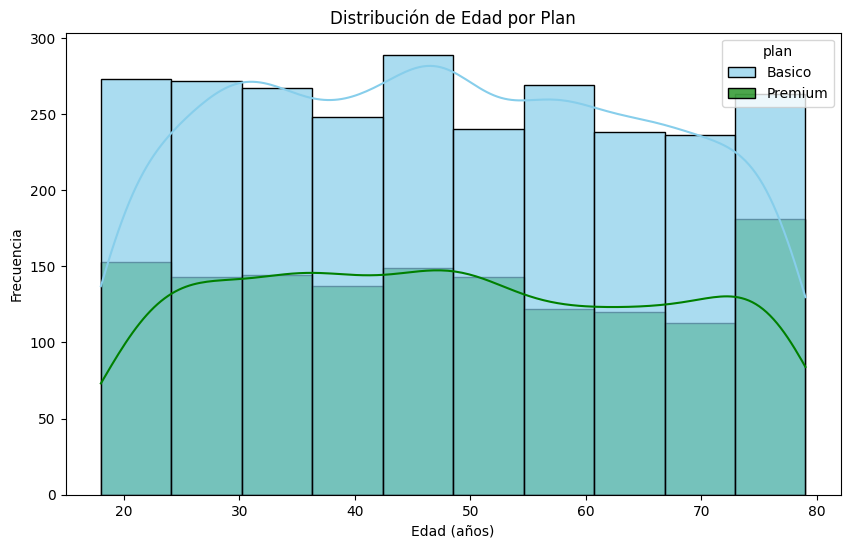

In [ ]:
# Histograma para visualizar la edad (age)

plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='age', hue='plan', bins=10,
             palette=['skyblue','green'], alpha=0.7, kde=True)
plt.title('Distribución de Edad por Plan')
plt.xlabel('Edad (años)')
plt.ylabel('Frecuencia')
plt.show()

💡Insights:
Se graficó según la edad y por tipo de plan, notando lo siguiente:
- Al enfocarnos solamente en la edad, podemos ver que las distribuciones son bastante homogéneas, sin haber picos que sobresalgan demasiado respecto a otros, siendo el más dominante el del grupo de 42 a 48 años, aunque sin diferenciarse demasiado de los demás grupos de edades.
- Al segmentar por tipo de plan, parece haber una cantidad de uso muy similar entre los diferentes grupos de edades, salvo para los adultos mayores que están en el rango de de 73 a 78 años, quienes usan más el plan Premium.

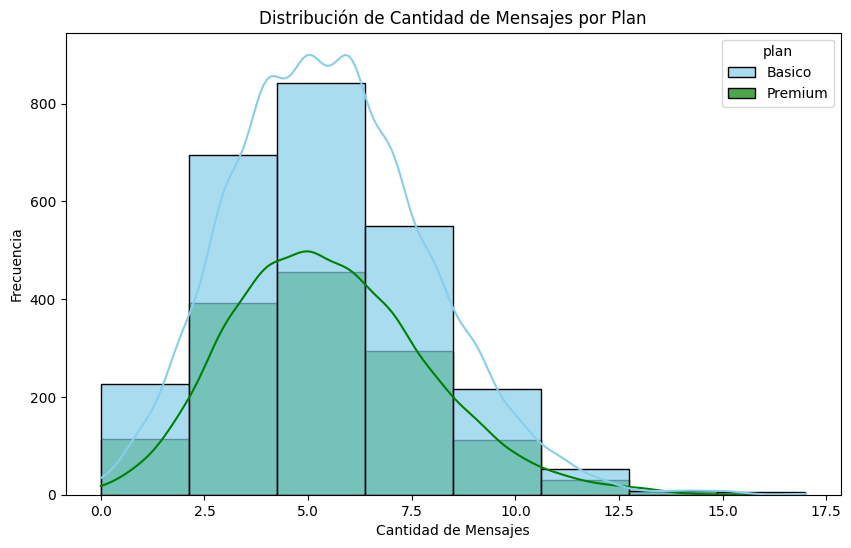

In [ ]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', bins=8,
             palette=['skyblue','green'], alpha=0.7, kde=True)
plt.title('Distribución de Cantidad de Mensajes por Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights:
-
Distribución con sesgo a la derecha por valores especialmente altos en el número de mensajes
- Tanto en el plan Básico como en el Premium, la mayoría de los usuarios envía entre 2 y 8 mensajes, siendo el pico mayor alrededor de 5 mensajes. Hay algunos pocos usuarios que envían más de 13 mensajes y eso es lo que genera el sesgo a la derecha.


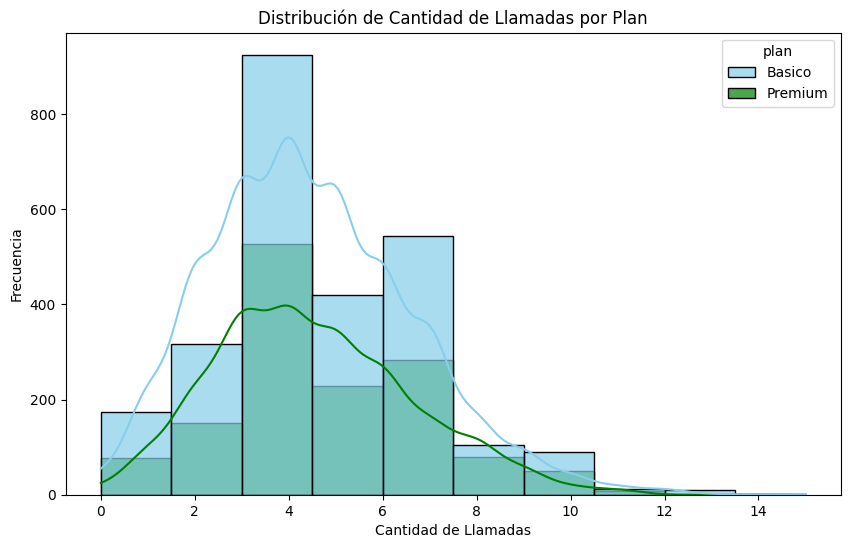

In [ ]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', bins=10,
             palette=['skyblue','green'], alpha=0.7, kde=True)
plt.title('Distribución de Cantidad de Llamadas por Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights:
- Distribución con sesgo a la derecha por valores especialmente altos en el número de llamadas
- Tanto en el plan Básico como en el Premium, la mayoría de los usuarios realiza entre 4 y 5 llamadas. La gran mayoría de los dats se concentran entre las 2 y las 7 u 8 llamadas. Hay algunos pocos usuarios que realizan más de 12 llamadas y eso es lo que genera el sesgo a la derecha.

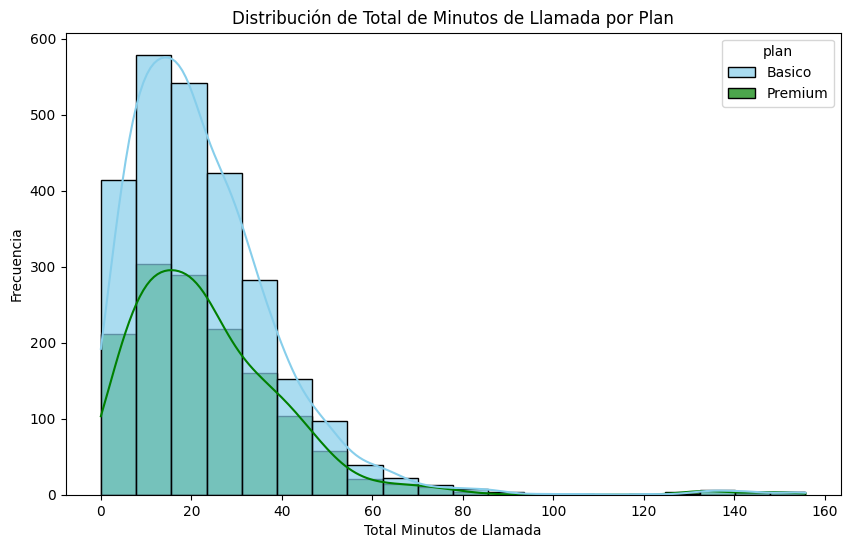

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', bins=20,
             palette=['skyblue','green'], alpha=0.7, kde=True)
plt.title('Distribución de Total de Minutos de Llamada por Plan')
plt.xlabel('Total Minutos de Llamada')
plt.ylabel('Frecuencia')
plt.show()

💡Insights:
- Se trata también de una distribución con sesgo a la derecha por un outlier en la duración de una llamada.
- La mayoría de la duración de las llamadas están entre 9 y 23 minutos, teniendo un pico en las llamadas de 10 a 12 minutos. Este comportamiento es muy homogéneo entre usuarios Básicos y Premium

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

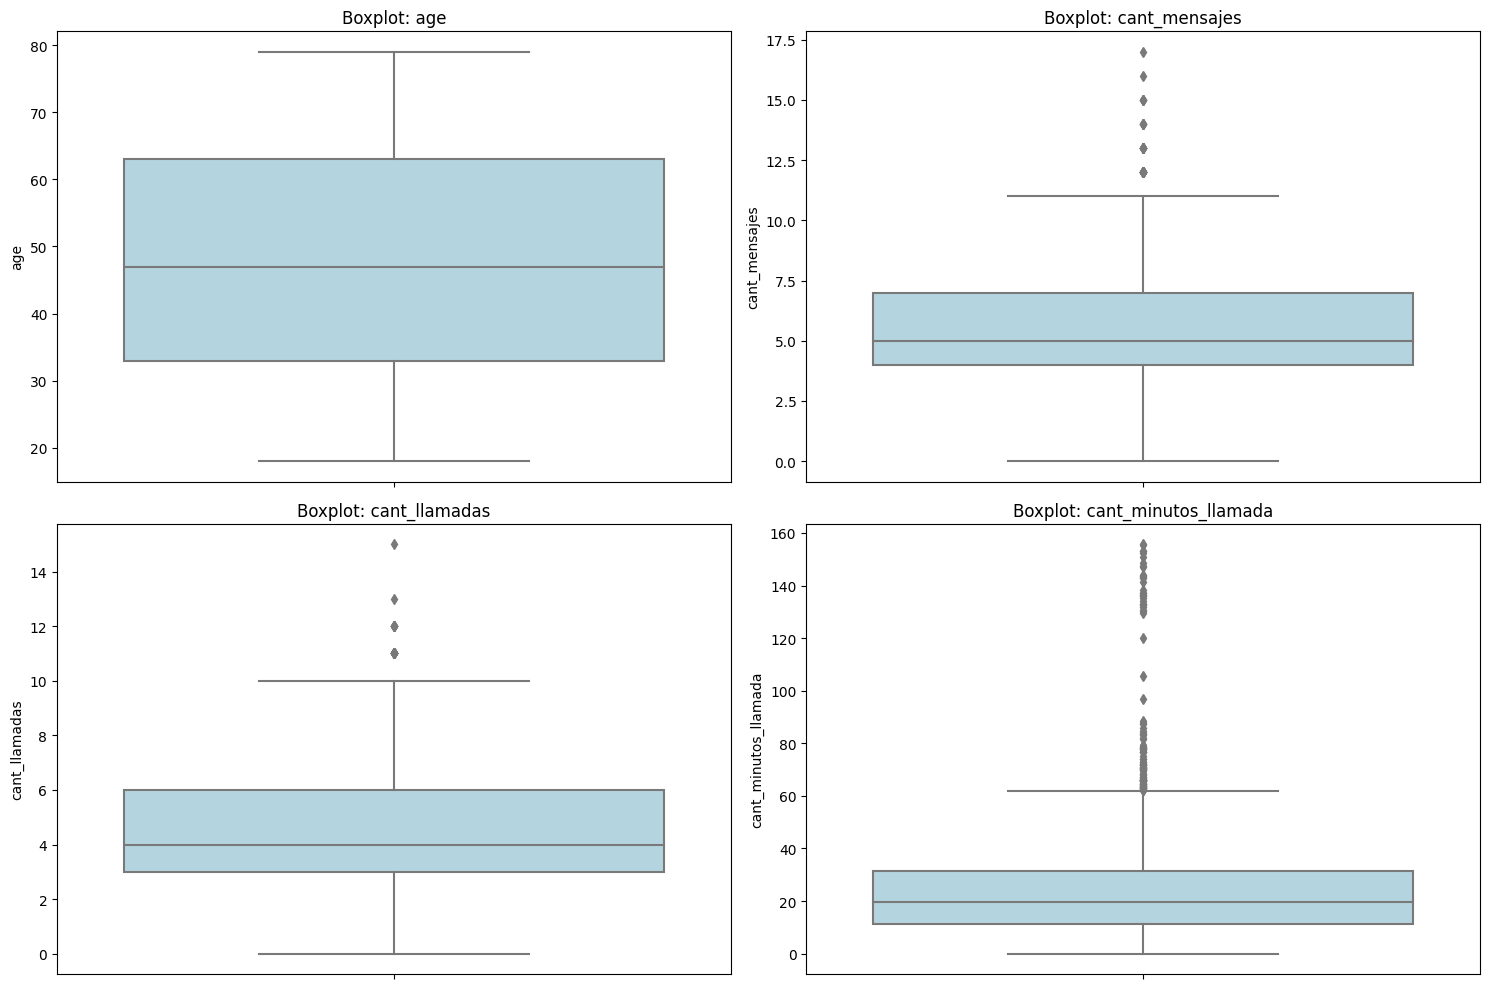

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

#for
# Crear boxplots automáticamente
plt.figure(figsize=(15, 10))

for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2, 2, i)  # 2 filas, 2 columnas
    sns.boxplot(data=user_profile, y=col, palette=['lightblue'])
    plt.title(f'Boxplot: {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

💡Insights:
- Age: es el más estable de los boxplots, ya que no presenta ningún outlier y las distancias entre los diferentes cuartiles son muy homogéneas
- cant_mensajes: tiene algunos outliers muy por encima del cuarto cuartil, que hacen que la media y la mediana no coincidan
- cant_llamadas: también cuenta con pocos outliers que elevan el promedio sobre la mediana
- cant_minutos_llamada: es la columna con mayor cantidad de outliers, que permite suponer que hay dos segmentos de clientes: una gran cantidad de ellos que realizan llamadas cortas y otro grupo más reducido que realizan llamadas muy largas (más de una hora)

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ["cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]

# Función para detectar outliers usando IQR
def detectar_outliers_iqr(user_profile, columnas_limites):
    Q1 = user_profile[columnas_limites].quantile(0.25)
    Q3 = user_profile[columnas_limites].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    return limite_inferior, limite_superior

# Analizar outliers en todas las columnas
print("=== ANÁLISIS DE OUTLIERS ===\n")

for col in columnas_limites:
    limite_inf, limite_sup = detectar_outliers_iqr(user_profile, col)

    # Contar outliers
    outliers_inf = (user_profile[col] < limite_inf).sum()
    outliers_sup = (user_profile[col] > limite_sup).sum()
    total_outliers = outliers_inf + outliers_sup

    print(f"--- {col.upper()} ---")
    print(f"Límite inferior: {limite_inf:.2f}")
    print(f"Límite superior: {limite_sup:.2f}")
    print(f"Outliers inferiores: {outliers_inf}")
    print(f"Outliers superiores: {outliers_sup}")
    print(f"Total outliers: {total_outliers}")
    print(f"Porcentaje de outliers: {(total_outliers/len(user_profile)*100):.2f}%")
    print("-" * 30)

=== ANÁLISIS DE OUTLIERS ===

--- CANT_MENSAJES ---
Límite inferior: -0.50
Límite superior: 11.50
Outliers inferiores: 0
Outliers superiores: 46
Total outliers: 46
Porcentaje de outliers: 1.15%
------------------------------
--- CANT_LLAMADAS ---
Límite inferior: -1.50
Límite superior: 10.50
Outliers inferiores: 0
Outliers superiores: 30
Total outliers: 30
Porcentaje de outliers: 0.75%
------------------------------
--- CANT_MINUTOS_LLAMADA ---
Límite inferior: -19.32
Límite superior: 61.86
Outliers inferiores: 0
Outliers superiores: 109
Total outliers: 109
Porcentaje de outliers: 2.73%
------------------------------


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: hay un total de 46 outliers, que representan apenas el 1.15% del total. Aunque es un porcentaje muy bajo, creo que lo mejor es mantenerlos porque pueden estar indicando a usuarios que hacen un uso mayor de mensajes de texto respecto al promedio.
- cant_llamadas: aquí solamente hay 30 outliers, que representa el 0.75% del total de llamadas. Es un porcentaje demasiado bajo, pero que representa algunos clientes que realizan una mayor cantidad de llamadas que el promedio. En este caso, habría que evaluar si se capan los valores o se eliminan
- cant_minutos_llamada: en este caso, hay 109 llamadas que superan el promedio de minutos por llamada, aunque de una manera muy exagerada. Se trata sin duda de llamadas muy excepcionales, algunas que llegan incluso casi a las 3hrs de duración. Lo mejor es quitarlas del análisis, pero revisarlas por separado y entender bajo qué contexto se están suscitando esas inusuales llamadas largas.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = np.where(
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    'Bajo uso',
    np.where(
        (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10),
        'Uso medio',
        'Alto uso'
    )
)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(
    user_profile['age'] < 30,
    'Joven',
    np.where(
        user_profile['age'] < 60,
        'Adulto',
        'Adulto Mayor'
    )
)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

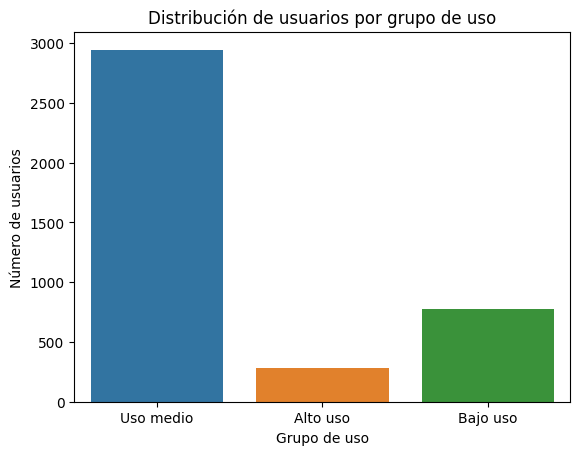

In [ ]:
# Visualización de los segmentos por uso

sns.countplot(data=user_profile, x='grupo_uso')

plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Número de usuarios')

plt.show()


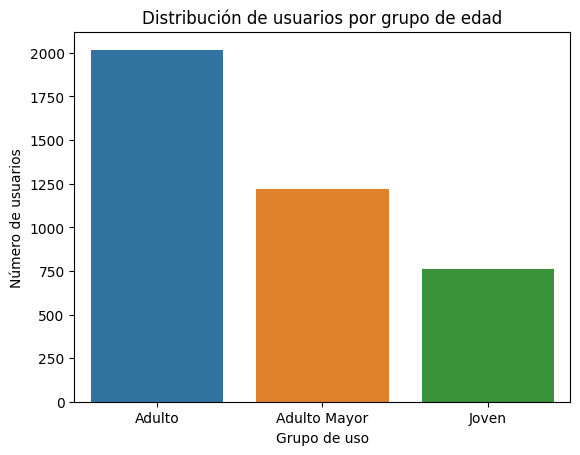

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')

plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de uso')
plt.ylabel('Número de usuarios')
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
Uno de los primeros problemas fue lidiar con los datos faltantes, que en algunas columnas como 'city' y 'churn_date' del Dataset "users" fueron algo significativas, mientras que aunque en "usage", las columnas 'duration' y 'lenght' tuvieron muchos faltantes, notamos que esto respondía al tipo de uso que se daba al télefono (llamada o mensaje).

Ya más avanzada la limpieza y depuración de los datos, se encontró que habían outliers considerables, pero poco numerosos en la cantidad de mensajes enviados, la cantidad de llamadas realizadas y la duración de algunas llamadas. Esos outliers deben revisarse para entender el contexto específico en el que están sucediendo.



- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?

Se diferenció a los usuarios según el nivel de uso y la edad, encontrando que una gran mayoría de ellos corresponden a adultos, es decir. entre 30 y 59 años de edad, así como una mayor preponderacia en el uso medio del teléfono, que consiste en el rango que va entre 5 y 10 llamadas y mensajes.



- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

En primer lugar, los Adultos de Alto Uso, quienes tienen mayor poder adquisitivo, hacen un mayor uso de los servicios y. al tener una mayor estabilidad laboral, se les pueden ofrecer servicios premium. Por otro lado, los Jovenes de Uso Medio son otro segmento importante por su potencial crecimiento en ingresos y su constante adopción de nuevas tecnologías.



- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

En realidad se encontraron outliers en el número de mensajes y llamadas realizadas, así como en la duración de algunas llamadas. Ninguno de estos outiers fue numeroso y nunca rebasó el 2.3%, pero me parece significativo que estos outliers estén presentes. Es por eso que decidí mantenerlos pero con la idea de analizar los contextos específicos en que se presentó cada uno de ellos para poder entender mejor porqué están ocurriendo y qué se puede potencialmente aprovechar de ellos.
Creo que estos datos inusuales, implican un patrón de uso muy diferenciado y puntual que ConnectaTel tiene que profundizar para entenderlo y explotar su potencial.


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

Definitivamente se tienen que crear planes según el perfil de los usuarios. Los jovenes tienden a utilizar más los datos y enviar mensajes de texto, mientras que por lo general los adultos mayores realizan más llamadas. Dado que la mayoría de los usuarios tienen una tendencia muy marcada hacia el Uso Medio de mensajes y llamadas (entre 5 y 10), habría que realizar planes que contengan un poco por encima de esta tendencia central para que los clientes no paguen de más por tener una cantidad demasiado alta de mensajes o minutos para llamar.

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Valores faltantes en algunas columnas no tan relevantes para los objetivos del presente análisis
- Valores atípicos o outliers en categrías como duración de las llamadas y cantidad de mensajes enviados y llamadas realizadas
- Necesidad de convertir algunos datos a otro formato (específicamente, a fechas)


🔍 **Segmentos por Edad**
- La mayoría de los usuarios son adultos entre 30 y 59 años de edad, mientras que los jovenes representan el segmento más bajo


📊 **Segmentos por Nivel de Uso**
- El Uso Medio, que maneja un rango de 5 a 10 mensajes y llamadas, fue el más popular, indicando que los usuarios no suelen exceder de esta cantidad (que realmente representa un envío de mensaje o realización de llamada cada tercer día)
- Sin embargo, hay outliers que demuestran que algunos pocos usuarios exceden por mucho en el envío de mensajes y realización de llamadas. Habría que comprender qué está sucediendo en esos casos específicos.


➡️ Esto sugiere que los planes deben adapatrse a las necesidades de los adultos, quienes suelen tneer mayor estabilidad laboral y por ende, se les pueden ofrecer planes premium más acoplados a sus necesidades de comunicación. Se debe profundizar en variables como la ubicación geográfica de esos usuarios para explorar potenciales promociones o creación de planes más adecuados a ese segmento


💡 **Recomendaciones**
- Analizar los outliers a detalle para comprender porqué están ocurriendo y bajo que circunstancias y contexto expecífico. Puede estar revelando un mercado muy segmentado que habría que diferenciar del de aquellos usuarios que se apegan más a las tendencias centrales
- Profundizar los grupos de edad mayoritarios (adultos) en cuanto a región donde residen y ver si hay alguno de los dos países donde predomine alguna otra variable que permita crear planes más diferenciados para cada país.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`